https://medium.com/analytics-vidhya/building-classification-model-with-python-9bdfc13faa4b

In [69]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.model_selection import GridSearchCV

from joblib import dump, load

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10,10)

In [70]:
"""
custom functions. Because we are going to compare multiple models,
we will re-use this function to keep things consistent.
"""
def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(X_test)

    #calc accuracy, precision, recall, F1 and kappa. See dendron notes for more.
    acc = metrics.accuracy_score(y_test, y_pred)
    prec = metrics.precision_score(y_test, y_pred)
    rec = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)
    kappa = metrics.cohen_kappa_score(y_test, y_pred)

    #calculate AOC. See dendron for explanation.
    # to get area under curve, need to calc curve first - assume this is roc?
    y_pred_proba = model.predict_proba(x_test)[::,1]
    fpr, tpr, _ = metrics.roc_curve(y_test, y_pred_proba)
    auc = metrics.roc_auc_score(y_test, y_pred)

    # show confusion matrix
    cm = metrics.confusion_matrix(y_test, y_pred)

    return{'acc': acc,
          'prec': prec,
          'rec': rec,
          'f1': f1,
          'kappa': kappa,
          'fpr': fpr,
          'tpr': tpr,
          'auc': auc,
          'cm':cm}

In [71]:
df_bank = pd.read_csv('https://raw.githubusercontent.com/rafiag/DTI2020/main/data/bank.csv')

In [72]:
df_bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


According to the dataset documentation, we need to remove the ‘duration’ column because in real-case the duration is only known after the label column is known. This problem can be considered to be ‘data leakage’ where predictors include data that will not be available at the time you make predictions.

In [73]:
if 'duration' in df_bank.columns:
    df_bank = df_bank.drop('duration', axis=1)
else:
    pass

In [74]:
# check distribution of the data. Want roughly 50:50
df_bank['deposit'].value_counts()

# also check for missing data
df_bank.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [75]:
# scale data using StandardScaler
df_bank_ready = df_bank.copy()

scaler = StandardScaler()

#We only scale the numeric columns, won't work on strings
num_cols = ['age', 'balance', 'day','campaign','pdays','previous']
df_bank_ready[num_cols] = scaler.fit_transform(df_bank[num_cols])

df_bank_ready.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,deposit
0,1.491505,admin.,married,secondary,no,0.252525,yes,no,unknown,-1.265746,may,-0.554168,-0.481184,-0.36326,unknown,yes
1,1.239676,admin.,married,secondary,no,-0.459974,no,no,unknown,-1.265746,may,-0.554168,-0.481184,-0.36326,unknown,yes
2,-0.019470,technician,married,secondary,no,-0.080160,yes,no,unknown,-1.265746,may,-0.554168,-0.481184,-0.36326,unknown,yes
3,1.155733,services,married,secondary,no,0.293762,yes,no,unknown,-1.265746,may,-0.554168,-0.481184,-0.36326,unknown,yes
4,1.071790,admin.,married,tertiary,no,-0.416876,no,no,unknown,-1.265746,may,-0.186785,-0.481184,-0.36326,unknown,yes


In [76]:
# categorical data will be encoded to numeric using OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
cat_cols = ['job','marital','education','default','housing','loan','contact','month','poutcome']

df_encoded = pd.DataFrame(encoder.fit_transform(df_bank_ready[cat_cols]))
df_encoded.columns = encoder.get_feature_names_out(cat_cols)

df_bank_ready = df_bank_ready.drop(cat_cols, axis=1)
df_bank_ready = pd.concat([df_encoded, df_bank_ready], axis=1)

df_bank_ready['deposit'] = df_bank_ready['deposit'].apply(lambda x: 1 if x=='yes' else 0)

print(f'shape of df: {df_bank_ready.shape}')
df_bank_ready.head()

shape of df: (11162, 51)


,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,poutcome_other,poutcome_success,poutcome_unknown,age,balance,day,campaign,pdays,previous,deposit
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.491505,0.252525,-1.265746,-0.554168,-0.481184,-0.36326,1
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.239676,-0.459974,-1.265746,-0.554168,-0.481184,-0.36326,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,-0.019470,-0.080160,-1.265746,-0.554168,-0.481184,-0.36326,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.155733,0.293762,-1.265746,-0.554168,-0.481184,-0.36326,1
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.071790,-0.416876,-1.265746,-0.186785,-0.481184,-0.36326,1


In [77]:
# split training/test data
feature = df_bank_ready.drop('deposit', axis=1)
target = df_bank_ready['deposit']

X_train, X_test, y_train, y_test = train_test_split(feature, target, 
                                                    shuffle = True, 
                                                    test_size=0.2, 
                                                    random_state=1)

print('Shape of training feature:', X_train.shape)
print('Shape of testing feature:', X_test.shape)
print('Shape of training label:', y_train.shape)
print('Shape of training label:', y_test.shape)

Shape of training feature: (8929, 50)
Shape of testing feature: (2233, 50)
Shape of training label: (8929,)
Shape of training label: (2233,)


In this step we will create a baseline model for each algorithm using the default parameters set by sklearn and after building all 4 of our models we will compare them to see which works best for our case. To evaluate our model we will use the confusion matrix as our base for the evaluation.

In [78]:
# build the decision tree model

dtc = tree.DecisionTreeClassifier(random_state=0)
dtc.fit(X_train, y_train)

# evaluate model
dtc_eval = evaluate_model(dtc, X_test, y_test)

# print results
print(f"acc: {dtc_eval['acc']}")
print(f"precision: {dtc_eval['prec']}")
print(f"recall: {dtc_eval['rec']}")
print(f"f1: {dtc_eval['f1']}")
print(f"cohens kappa: {dtc_eval['kappa']}")
print(f"auc: {dtc_eval['auc']}")
print(f"matrix: {dtc_eval['cm']}")

acc: 0.6336766681594268
precision: 0.6215953307392996
recall: 0.598314606741573
f1: 0.6097328244274809
cohens kappa: 0.2648219403033133
auc: 0.6322045136712157
matrix: [[776 389]
 [429 639]]


In [79]:
rf = RandomForestClassifier(random_state=0)
rf.fit(X_train, y_train)

# evaluate model
rf_eval = evaluate_model(rf, X_test, y_test)

# print results
print(f"acc: {rf_eval['acc']}")
print(f"precision: {rf_eval['prec']}")
print(f"recall: {rf_eval['rec']}")
print(f"f1: {rf_eval['f1']}")
print(f"cohens kappa: {rf_eval['kappa']}")
print(f"auc: {rf_eval['auc']}")
print(f"matrix: {rf_eval['cm']}")

acc: 0.7205553067622034
precision: 0.7488789237668162
recall: 0.6254681647940075
f1: 0.6816326530612244
cohens kappa: 0.43618595045335207
auc: 0.7165967433412097
matrix: [[941 224]
 [400 668]]


In [80]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# evaluate model
knn_eval = evaluate_model(knn, X_test, y_test)

# print results
print(f"acc: {knn_eval['acc']}")
print(f"precision: {knn_eval['prec']}")
print(f"recall: {knn_eval['rec']}")
print(f"f1: {knn_eval['f1']}")
print(f"cohens kappa: {knn_eval['kappa']}")
print(f"auc: {knn_eval['auc']}")
print(f"matrix: {knn_eval['cm']}")

acc: 0.6869682042095835
precision: 0.6981740064446831
recall: 0.6086142322097379
f1: 0.6503251625812907
cohens kappa: 0.3693851405429406
auc: 0.6837062577357702
matrix: [[884 281]
 [418 650]]


In [81]:
nb = GaussianNB()
nb.fit(X_train, y_train)

# evaluate model
nb_eval = evaluate_model(nb, X_test, y_test)

# print results
print(f"acc: {nb_eval['acc']}")
print(f"precision: {nb_eval['prec']}")
print(f"recall: {nb_eval['rec']}")
print(f"f1: {nb_eval['f1']}")
print(f"cohens kappa: {nb_eval['kappa']}")
print(f"auc: {nb_eval['auc']}")
print(f"matrix: {nb_eval['cm']}")

acc: 0.6815942678011644
precision: 0.7560975609756098
recall: 0.4934456928838951
f1: 0.5971671388101983
cohens kappa: 0.352622455965517
auc: 0.6737614730513894
matrix: [[995 170]
 [541 527]]


### Model comparison

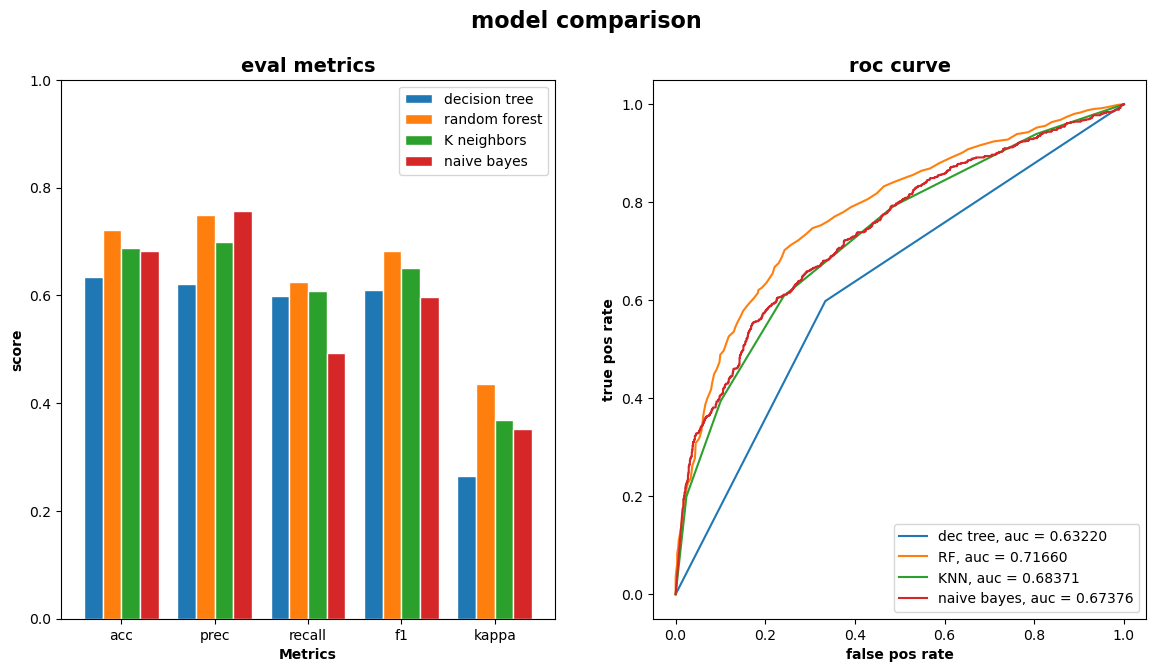

In [90]:
fig, (ax1, ax2) = plt.subplots(1,2)
fig.suptitle('model comparison', fontsize=16, fontweight='bold')
fig.set_figheight(7)
fig.set_figwidth(14)
fig.set_facecolor('white')

#first plot
barWidth = 0.2
dtc_score = [dtc_eval['acc'], dtc_eval['prec'], dtc_eval['rec'], dtc_eval['f1'], dtc_eval['kappa']]
rf_score = [rf_eval['acc'], rf_eval['prec'], rf_eval['rec'], rf_eval['f1'], rf_eval['kappa']]
nb_score = [nb_eval['acc'], nb_eval['prec'], nb_eval['rec'], nb_eval['f1'], nb_eval['kappa']]
knn_score = [knn_eval['acc'], knn_eval['prec'], knn_eval['rec'], knn_eval['f1'], knn_eval['kappa']]
#set positions on x axis
r1 = np.arange(len(dtc_score))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]

# make the plot
ax1.bar(r1, dtc_score, width=barWidth, edgecolor='white', label='decision tree')
ax1.bar(r2, rf_score, width=barWidth, edgecolor='white', label='random forest')
ax1.bar(r3, knn_score, width=barWidth, edgecolor='white', label='K neighbors')
ax1.bar(r4, nb_score, width=barWidth, edgecolor='white', label='naive bayes')

# configure x and y axes

ax1.set_xlabel('Metrics', fontweight='bold')
labels = ['acc','prec','recall','f1','kappa']
ax1.set_xticks([r + (barWidth * 1.5) for r in range(len(dtc_score))],)
ax1.set_xticklabels(labels)
ax1.set_ylabel('score', fontweight='bold')
ax1.set_ylim(0,1)

#title and legend
ax1.set_title('eval metrics', fontsize=14, fontweight='bold')
ax1.legend()

# second plot
ax2.plot(dtc_eval['fpr'], dtc_eval['tpr'], label='dec tree, auc = {:0.5f}'.format(dtc_eval['auc']))
ax2.plot(rf_eval['fpr'], rf_eval['tpr'], label='RF, auc = {:0.5f}'.format(rf_eval['auc']))
ax2.plot(knn_eval['fpr'], knn_eval['tpr'], label='KNN, auc = {:0.5f}'.format(knn_eval['auc']))
ax2.plot(nb_eval['fpr'], nb_eval['tpr'], label='naive bayes, auc = {:0.5f}'.format(nb_eval['auc']))

# config x and y labels
ax2.set_xlabel('false pos rate', fontweight='bold')
ax2.set_ylabel('true pos rate', fontweight='bold')

#legend and title
ax2.set_title('roc curve', fontsize=14, fontweight='bold')
ax2.legend(loc=4)

plt.show()

We can see that our Random Forest model tops the other models in 5 of the 6 metrics we evaluate, except precision. So we can assume that Random Forest is the right choice to solve our problem.

## model optimisation

tune the model and compare it to the original RF to see if it improves.

#### hyper parameters and tuning them with GridSearchCB

`GridSearchCV` helps us find the optimal parameter for the mode. Give it the baseline mode, scoring method (in this case recall) and parameters we want to try with the model. The function will then iterate through each param combination to find the best scoring ones.

This also allows us to **use cross validation to train the model**, where on each iteration the data is divided into 5 fold. the models are then trained on 4/5 fold of the data leaving the final fold as validation data. This is repeated 5 times until all folds are used as validation data. 

In [91]:
param_grid = {
    'max_depth': [50, 80, 100],
    'max_features': [2,3,4],
    'min_samples_leaf': [3,4,5],
    'min_samples_split': [8,10,12],
    'n_estimators': [100,300,500,750,1000]
}

# create the base model
rf_grids = RandomForestClassifier(random_state=0)

#start the grid search
grid_search = GridSearchCV(estimator=rf_grids, 
                           param_grid=param_grid, 
                           scoring='recall', 
                           cv=5, 
                           n_jobs=-1, 
                           verbose=2)

# fit the grid search to the data
grid_search.fit(X_train, y_train)

grid_search.best_params_

Fitting 5 folds for each of 405 candidates, totalling 2025 fits
[CV] END max_depth=50, max_features=2, min_samples_leaf=3, min_samples_split=8, n_estimators=100; total time=   0.5s
[CV] END max_depth=50, max_features=2, min_samples_leaf=3, min_samples_split=8, n_estimators=100; total time=   0.5s
[CV] END max_depth=50, max_features=2, min_samples_leaf=3, min_samples_split=8, n_estimators=300; total time=   1.4s
[CV] END max_depth=50, max_features=2, min_samples_leaf=3, min_samples_split=8, n_estimators=300; total time=   1.3s
[CV] END max_depth=50, max_features=2, min_samples_leaf=3, min_samples_split=8, n_estimators=300; total time=   1.4s
[CV] END max_depth=50, max_features=2, min_samples_leaf=3, min_samples_split=8, n_estimators=500; total time=   2.2s
[CV] END max_depth=50, max_features=2, min_samples_leaf=3, min_samples_split=8, n_estimators=500; total time=   2.1s
[CV] END max_depth=50, max_features=2, min_samples_leaf=3, min_samples_split=8, n_estimators=750; total time=   3.4s


{'max_depth': 50,
 'max_features': 4,
 'min_samples_leaf': 3,
 'min_samples_split': 10,
 'n_estimators': 750}

In [92]:
# now select model with best fit

best_grid = grid_search.best_estimator_

#eval model
best_grid_eval = evaluate_model(best_grid, X_test, y_test)

print(f"acc: {best_grid_eval['acc']}")
print(f"precision: {best_grid_eval['prec']}")
print(f"recall: {best_grid_eval['rec']}")
print(f"f1: {best_grid_eval['f1']}")
print(f"cohens kappa: {best_grid_eval['kappa']}")
print(f"auc: {best_grid_eval['auc']}")
print(f"cm: {best_grid_eval['cm']}")

acc: 0.7241379310344828
precision: 0.7736077481840193
recall: 0.598314606741573
f1: 0.6747624076029567
cohens kappa: 0.4419687736058022
auc: 0.7188997926411728
cm: [[978 187]
 [429 639]]


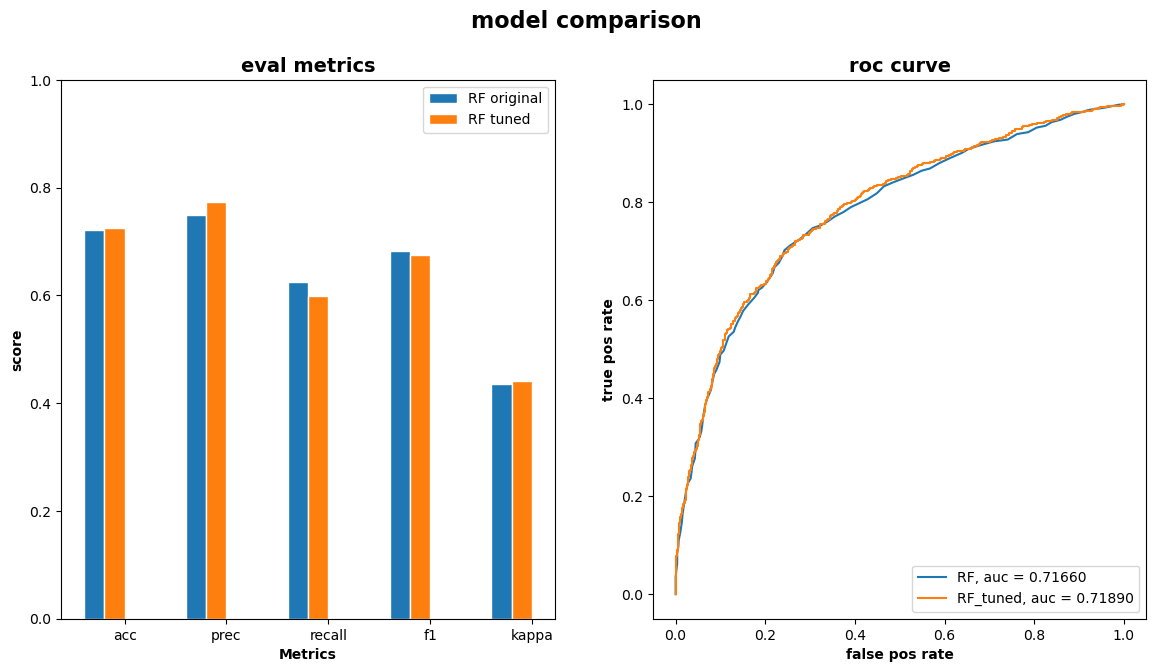

[CV] END max_depth=100, max_features=4, min_samples_leaf=5, min_samples_split=8, n_estimators=500; total time=   2.6s
[CV] END max_depth=100, max_features=4, min_samples_leaf=5, min_samples_split=8, n_estimators=500; total time=   2.6s
[CV] END max_depth=100, max_features=4, min_samples_leaf=5, min_samples_split=8, n_estimators=750; total time=   4.2s
[CV] END max_depth=100, max_features=4, min_samples_leaf=5, min_samples_split=8, n_estimators=750; total time=   4.0s
[CV] END max_depth=100, max_features=4, min_samples_leaf=5, min_samples_split=8, n_estimators=750; total time=   4.1s
[CV] END max_depth=100, max_features=4, min_samples_leaf=5, min_samples_split=8, n_estimators=1000; total time=   5.3s
[CV] END max_depth=100, max_features=4, min_samples_leaf=5, min_samples_split=8, n_estimators=1000; total time=   5.2s
[CV] END max_depth=100, max_features=4, min_samples_leaf=5, min_samples_split=10, n_estimators=100; total time=   0.6s
[CV] END max_depth=100, max_features=4, min_samples_l

In [96]:
fig, (ax1, ax2) = plt.subplots(1,2)
fig.suptitle('model comparison', fontsize=16, fontweight='bold')
fig.set_figheight(7)
fig.set_figwidth(14)
fig.set_facecolor('white')

#first plot
barWidth = 0.2
rf_score = [rf_eval['acc'], rf_eval['prec'], rf_eval['rec'], rf_eval['f1'], rf_eval['kappa']]
rf_grid_score = [best_grid_eval['acc'], best_grid_eval['prec'], best_grid_eval['rec'], best_grid_eval['f1'], best_grid_eval['kappa']]
#set positions on x axis
r1 = np.arange(len(rf_score))
r2 = [x + barWidth for x in r1]

# make the plot
ax1.bar(r1, rf_score, width=barWidth, edgecolor='white', label='RF original')
ax1.bar(r2, rf_grid_score, width=barWidth, edgecolor='white', label='RF tuned')

# configure x and y axes

ax1.set_xlabel('Metrics', fontweight='bold')
labels = ['acc','prec','recall','f1','kappa']
ax1.set_xticks([r + (barWidth * 1.5) for r in range(len(rf_score))],)
ax1.set_xticklabels(labels)
ax1.set_ylabel('score', fontweight='bold')
ax1.set_ylim(0,1)

#title and legend
ax1.set_title('eval metrics', fontsize=14, fontweight='bold')
ax1.legend()

# second plot
ax2.plot(rf_eval['fpr'], rf_eval['tpr'], label='RF, auc = {:0.5f}'.format(rf_eval['auc']))
ax2.plot(best_grid_eval['fpr'], best_grid_eval['tpr'], label='RF_tuned, auc = {:0.5f}'.format(best_grid_eval['auc']))

# config x and y labels
ax2.set_xlabel('false pos rate', fontweight='bold')
ax2.set_ylabel('true pos rate', fontweight='bold')

#legend and title
ax2.set_title('roc curve', fontsize=14, fontweight='bold')
ax2.legend(loc=4)

plt.show()

## now we've done all that, actually use the model to predict things.

### Should also save the model so you don't have to train it again...since that took ages.
can use `joblib` for this

In [ ]:
df_bank['deposit_prediction'] = rf.predict(feature)
df_bank['deposit_prediction'] = df_bank['deposit_prediction'].apply(lambda x: 'yes' if x==0 else 'no')

df_bank.head(10)

In [ ]:
#save out model to re-use later
# keep commented out as we don't actually want to save

#dump(rf, 'bank_deposit_classification.joblib')

# if you want to load the model
# clf = load('bank_deposit_classification.joblib')

For a simple model we can see that our model did decently on classifying the data. But there are still some weakness on our model, especially shown on the recall metric where we only get about 60%. This means that our model are only able to detect 60% of potential customer and miss the other 40%. The result is not that much different after optimising the model using GridSearchCV which can means that we hit our limit with this model. To improve our performance we can try to look into another algorithm such as GradientBoostingClassifier.